In [1]:
"""Scripts for analyzing of phantom outputs.

This script generate lightcurves (LC) by doing radiative transfer on a grid generated by splash to grid.


-------------------------------------------------------------------------------

Side note: Remember to limit line length to 79 characters according to PEP-8
    https://peps.python.org/pep-0008/#maximum-line-length    
which is the length of below line of '-' characters.

-------------------------------------------------------------------------------

"""

"Scripts for analyzing of phantom outputs.\n\nThis script generate lightcurves (LC) by doing radiative transfer on a grid generated by splash to grid.\n\n\n-------------------------------------------------------------------------------\n\nSide note: Remember to limit line length to 79 characters according to PEP-8\n    https://peps.python.org/pep-0008/#maximum-line-length    \nwhich is the length of below line of '-' characters.\n\n-------------------------------------------------------------------------------\n\n"

.

## Def

.

In [2]:
import numpy as np
from numpy import pi
from astropy import units
from astropy import constants as const
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.typing import ColorType
import matplotlib as mpl
from numba import jit,njit, prange
import sarracen
import itertools
from scipy import integrate, fft
from scipy.spatial import KDTree
from scipy.optimize import curve_fit
from datetime import datetime
import os
from os.path import sep
# fix weird moviepy cannot find my ffmpeg exe error
try: import moviepy
except RuntimeError: os.environ["IMAGEIO_FFMPEG_EXE"] = "/usr/bin/ffmpeg"
try: from moviepy import ImageSequenceClip, concatenate_videoclips
except ImportError: from moviepy.editor import ImageSequenceClip, concatenate_videoclips
import gc
#from os import path

In [3]:
# import my modules listed in ./main/

import clmuphantomlib as mupl
from clmuphantomlib            import MyPhantomDataFrames, get_eos, get_eos_opacity, get_col_kernel_funcs
from clmuphantomlib.log        import is_verbose, say
from clmuphantomlib.settings   import DEFAULT_SETTINGS as settings
from clmuphantomlib.units_util import get_val_in_unit, set_as_quantity #, get_units_field_name, get_units_cgs
from clmuphantomlib.io         import json_dump, json_load, hdf5_dump, hdf5_load
from clmuphantomlib.eos.mesa   import EoS_MESA_opacity
from clmuphantomlib.light      import get_optical_depth_by_ray_tracing_3D, get_photosphere_on_ray

from multiprocessing import cpu_count, Pool #Process, Queue
NPROCESSES = 1 if cpu_count() is None else max(cpu_count(), 1)

In [4]:
# settings
#
#   imported from script_input.py file


from script_LCGen__input import verbose, verbose_loop, interm_dir, output_dir, unitsOut, SPEC_DIST, PHOTOSPHERE_TAU, JOB_PROFILES_DICT
from script_LCGen import get_sph_neighbours
from _sharedFuncs import mpdf_read, pa_read_energy, pa_read_ev

# remove temp flag
interm_dir = interm_dir.split('test_')[0]
interm_dir = interm_dir.split('Tscale_')[0]
interm_dir = interm_dir.split('Tcut_')[0]
interm_dir = interm_dir.split('Tdelete_')[0]
# interm_dir = interm_dir.split('olim_')[0]


unitsOutTxt = {  key  : unitsOut[key].to_string('latex_inline') for key in unitsOut.keys() }

spec_dist = SPEC_DIST

# set metadata
with open("_metadata__input.json", 'r') as f:
    metadata = json_load(f)
metadata['Title'] = "Getting light curves by intergrating across a grid of rays"
metadata['Description'] = f"""Getting light curves by intergrating across a grid of rays with the same directions
for dump file data generated by phantom
"""


plt.rcParams.update({'font.size': 20})
if __name__ == '__main__' and is_verbose(verbose, 'note'):
    # remember to check if name is '__main__' if you wanna say anything
    #    so when you do multiprocessing the program doesn't freak out
    say('note', None, verbose, f"{interm_dir = }")
    say('note', None, verbose, f"Will use {NPROCESSES} processes for parallelization")


*   Note   :    run_ast_nodes() ==> run_code() ==> <module>():
	interm_dir = '../interm/'
*   Note   :    run_ast_nodes() ==> run_code() ==> <module>():
	Will use 8 processes for parallelization


In [5]:
from clmuphantomlib.log import say, is_verbose
from clmuphantomlib.geometry import get_dist2_between_2pt, get_closest_pt_on_line
from clmuphantomlib.sph_interp import get_sph_interp, get_h_from_rho, get_no_neigh, _get_sph_interp_phantom_np
from clmuphantomlib.units_util import set_as_quantity, set_as_quantity_temperature, get_units_field_name, DEFAULT_UNITS
from clmuphantomlib.eos   import EoS_Base
from clmuphantomlib.light import integrate_along_ray_grid, integrate_along_ray_gridxy

#  import (general)
import numpy as np
import numba
from numba import jit, njit, prange
import sarracen
from scipy.stats import linregress

from clmuphantomlib.geometry import get_dist2_from_pts_to_line, get_dist2_from_pt_to_line_nb, get_ray_unit_vec, get_rays_unit_vec

## Main

In [6]:
def xyz_to_rtp(xyzs):
    """Convert castesian coordinates to spherical coordinates"""
    rs = np.sqrt(np.sum(xyzs**2, axis=1))
    thetas = np.acos(xyzs[:, 2] / rs)
    phis = np.atan2(xyzs[:, 1], xyzs[:, 0])
    return rs, thetas, phis

def rtp_to_xyz(rs, thetas, phis):
    """Convert spherical coordinates to castesian coordinates"""
    xs = rs * np.sin(thetas) * np.cos(phis)
    ys = rs * np.sin(thetas) * np.sin(phis)
    zs = rs * np.cos(thetas)
    return np.stack((xs, ys, zs), axis=1)

In [20]:
# params

nn = '2md'
file_index = 800
kappa_gas : units.Quantity = 2e-4*(units.cm**2/units.g)
T_cond_oxy: units.Quantity = 1450 * units.K
ndim = 3
do_extrap = False
verbose = True

job_profile = JOB_PROFILES_DICT[nn]
job_profile['ieos'] = 10    # temp override
eos = get_eos(job_profile['ieos'], job_profile['params'])
eos_opacity = get_eos_opacity(ieos=job_profile['ieos'], params=job_profile['params'])
dump_filename = f"{job_profile['job_name']}_{file_index:05}"

mpdf = mupl.MyPhantomDataFrames()
mpdf.read(f"{job_profile['job_name']}", file_index, reset_xyz_by='R1', calc_params=['vr', 'R1'], verbose=verbose)
mpdf.data['gas']['T'] = eos.get_temp(mpdf.get_val('rho'), mpdf.get_val('u'))

if True:
    kappa_mesa = eos_opacity.get_kappa(mpdf.get_val('rho'), mpdf.get_val('T'), do_extrap=do_extrap)
    mpdf.data['gas']['kappa'] = np.where(
        mpdf.data['gas']['T'] < T_cond_oxy.to_value(mpdf.units['temp']),
        kappa_gas.to_value( mpdf.units['opacity']),
        kappa_mesa.to_value(mpdf.units['opacity']),
    )

hfact = mpdf.params['hfact']
kernel = mpdf.data['gas'].kernel
kernel_radius = kernel.get_radius()
sdf = mpdf.data['gas']

kernel_col, kernel_csz, _, _ = get_col_kernel_funcs(kernel)

mpdf.data['sink']

*   Note   :    run_code() ==> <module>() ==> read():
	

	Reading filename='../raw/luis_2md/light_00800'


    Debug  :    run_code() ==> <module>() ==> read():
	udist = 1.00036 solRad
	umass = 1.00035 solMass
	utime = 1.00053 unit_time
	self.time = np.float64(40000.0)
self.gamma = np.float64(1.6666666666666667)
self.ieos = 10
self.total_mass = np.float64(2.3056731566759385)

	Center of mass location: self.loc_CoM = array([-0.26338689,  0.20393866, -0.11466218])

*   Note   :    <module>() ==> read() ==> reset_xyz_by():
	Reseting Origin to R1 ([-22.55044572 129.62639629  -0.53150014])...
*   Note   :    <module>() ==> read() ==> reset_xyz_by():
	CoM location is now [  22.28705883 -129.42245762    0.41683796]
**  Warning:    run_code() ==> <module>() ==> read():
	kappa column exists.
	We here assume kappa is in phantom units self.units['opacity']=Unit("udist2 / umass") 
	However in phantom kappa is assumed to be in cgs unit.
	If so, please CONVERT KAPPA MANNUALLY into PHANTOM units BEFO

,x,y,z,m,h,hsoft,maccreted,spinx,spiny,spinz,...,lum,Teff,Reff,mdotloss,mdotav,mprev,massenc,vx,vy,vz
0,0.000000,0.000000,0.000000,0.56392,0.0,2.0,0.0,-1.559169e-14,-2.654994e-14,-4.053202e-12,...,1.077725e-08,0.0,0.0,0.0,0.0,0.0,0.003717,-0.018045,-0.004621,0.000172
1,93.570076,-461.862155,1.211067,0.60000,0.0,2.0,0.0,2.114194e-16,-4.926615e-16,3.073097e-13,...,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000050,0.048539,0.014958,-0.000028


In [21]:

npart = len(sdf)
xyzs = np.asarray(sdf[['x', 'y', 'z']])
r2s = np.sum(xyzs**2, axis=1)
order = np.argsort(r2s)[::-1]

xyzs_ordered = xyzs[order]
rs_ordered, thetas_ordered, phis_ordered = xyz_to_rtp(xyzs[order])

hs_ordered = np.asarray(sdf['h'])[order]
ms_ordered = np.asarray(sdf['m'])[order]
kappas_ordered= np.asarray(sdf['kappa'])[order]

hprs_ordered = hs_ordered / rs_ordered

# sdf_kdtree = KDTree(xyzs)

dtaus_ordered = kappas_ordered * ms_ordered / hs_ordered**2 * kernel_col(0, ndim)

In [22]:
# coordinates conversion safety check
assert np.allclose(xyzs_ordered, rtp_to_xyz(rs_ordered, thetas_ordered, phis_ordered))

In [23]:

# taus = dtaus.copy()


@njit(parallel=True, fastmath=True)
def func(
    dtaus_ordered,
    xyzs_ordered,
    rs_ordered,
    hprs_ordered,    # h / r
    w_rad: float,
    tau_max: float = 20.0
):

    npart = len(dtaus_ordered)
    taus_ordered = dtaus_ordered.copy()
    
    for i in prange(npart):
        x_i, y_i, z_i = xyzs_ordered[i]
        r_i = rs_ordered[i]
        r2_i = r_i**2
        hpr_i = hprs_ordered[i]
        for j in range(0, i):
            x_j, y_j, z_j = xyzs_ordered[j]

            # check if the point is further away from the center in the direction of vec_i
            dot_product = x_i*x_j + y_i*y_j + z_i*z_j
            if dot_product < r2_i:
                continue

            r_j = rs_ordered[j]
            hpr_j = hprs_ordered[j]

            # check if part j overlaps with part i
            #    alpha is the angle between vec_j and vec_i
            cos_alpha = dot_product / (r_i * r_j)
            sin2_alpha = 1 - cos_alpha**2
            if sin2_alpha < (hpr_i * cos_alpha + hpr_j)**2:
                continue
            
            taus_ordered[i] += dtaus_ordered[j]
            if taus_ordered[i] > tau_max:
                break
            # x_j, y_j, z_j = xyzs[j]
            # hr_j  = hs[j]*w_rad
            # # check if the particle is within range
            # if (    x_i - hr_i < x_j + hr_j and x_j - hr_j < x_i + hr_i
            #     and y_i - hr_i < y_j + hr_j and y_j - hr_j < y_i + hr_i
            #     and z_i - hr_i < z_j + hr_j and z_j - hr_j < z_i + hr_i
            #    ):
            #     taus[i] += 1

    return taus_ordered

taus_ordered = func(dtaus_ordered, xyzs_ordered, rs_ordered, hs_ordered/rs_ordered, w_rad=kernel_radius)
sdf['tau'] = 0.0
sdf.loc[order, 'tau'] = taus_ordered
sdf.loc[order, 'dtau'] = dtaus_ordered

In [24]:
output_dir = f"..{sep}fig{sep}20260511_APR-test{sep}"
output_dir

'../fig/20260511_APR-test/'

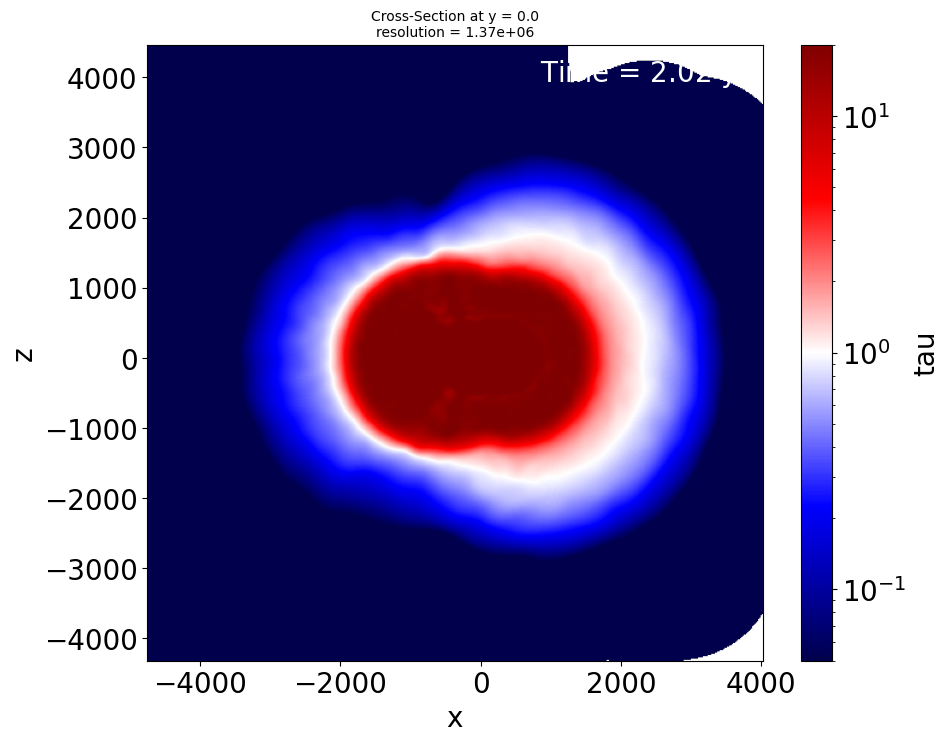

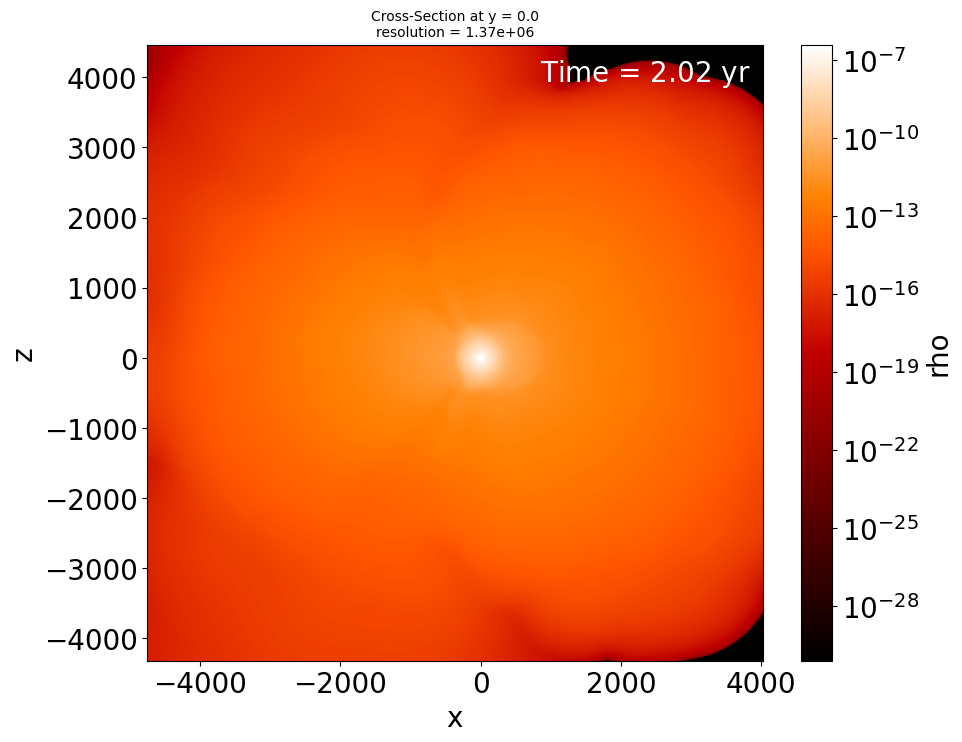

In [25]:
for xyz_axis in ['xyz', 'yzx', 'xzy']:
    plt.close('all')
    fig, ax = mpdf.plot_render(rendered='tau', xyz_axis=xyz_axis, xsec=0.0, norm=mpl.colors.LogNorm(0.05, 20), cmap='seismic')
    fig.savefig(f"{output_dir}{nn}_{file_index:05d}_{xyz_axis}_tau_xsec.png")
    fig, ax = mpdf.plot_render(rendered='rho', xyz_axis=xyz_axis, xsec=0.0)
    fig.savefig(f"{output_dir}{nn}_{file_index:05d}_{xyz_axis}_rho_xsec.png")

In [13]:
np.count_nonzero(sdf['dtau'][order]<1)

np.int64(140874)

In [14]:
np.min(sdf['dtau'][order])

1.1709549710075218e-06

In [15]:
from numba.cuda.cudadrv import nvvm
n = nvvm.NVVM()
n.supported_ccs

((5, 0),
 (5, 2),
 (5, 3),
 (6, 0),
 (6, 1),
 (6, 2),
 (7, 0),
 (7, 2),
 (7, 5),
 (8, 0),
 (8, 6),
 (8, 7),
 (8, 9),
 (9, 0))

In [16]:
from numba import cuda
print(cuda.get_current_device().compute_capability)

(6, 1)
